<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap5_StableDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

５章 Stable Diffusion と条件付き生成

前章までで画像の生成はできるようになったが、モデルの訓練には時間がかかり、生成される画像を制御することはできなかった。
本章ではより発展的に、テキストの説明に基づいて効率的に画像を生成できる、テキスト条件付きモデルへと発展させる方法を、Stable Diffusion を事例として見ていく。

その前に、まず条件付きモデルがどのように動作するかを確認し、現在のテキストから画像への生成モデルにつながる技術革新について振り返る。

5.1 制御の追加：条件付き拡散モデル

モデルの出力を制御する方法の一つに**条件付け**がある。
これはモデルに対して「どんな画像でも良い」とするのではなく、「あらかじめ決められたクラスに属する画像を生成せよ」と指示を与えるもの。
生成の過程でラベルやプロンプトなどの追加情報を与え、モデルの出力を誘導することを指す。

データセットは前章の蝶の画像の代わりに、画像にクラスラベルが付与された衣服画像のデータセットを用いる。
ポイントは、画像に加えて、画像が属するクラスラベルも入力に用いる点。
これによりモデルが画像とラベルの間の関連性を学び、特徴を理解できるようになることを期待する。

分類問題を解決することを目的としていない点に注意。
目的は前章と同じく、使用するデータセットから生成されたような最もらしい画像を生成させたいということ。
訓練の方法や損失関数は前章と同じものを使う。なぜなら本質的には本章でも同じタスクだから。

5.1.1 データの準備

今回は Fashion MNIST を使う。

In [3]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

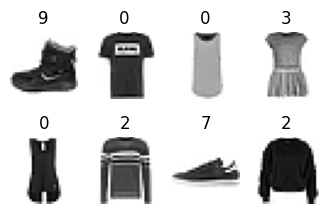

In [4]:
import matplotlib as mpl
from datasets import load_dataset

from genaibook.core import show_images

mpl.rcParams["image.cmap"] = "gray_r"

fashion_mnist = load_dataset("fashion_mnist")
clothes = fashion_mnist["train"]["image"][:8]
classes = fashion_mnist["train"]["label"][:8]
show_images(clothes, titles=classes, figsize=(4, 2.5))

今回は画像を 32 * 32 ピクセルにパディングする。

In [5]:
import torch
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Pad(2),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

def transform(examples):
  images = [preprocess(image) for image in examples["image"]]
  return {"images": images, "labels": examples["label"]}


train_dataset = fashion_mnist["train"].with_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True
)

5.1.2 クラス条件付きモデルの作成

UNet はカスタムの条件付け情報を与えることができる。
コンストラクタに num_class_embeds を追加するだけ。
Fashion MNIST のクラスすうが１０個なので、この引数に渡す値も１０とする。

In [6]:
from diffusers import UNet2DModel

model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    sample_size=32,
    block_out_channels=(32, 64, 128, 256),
    num_class_embeds=10
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


このモデルで予測を行うには forward() メソッドにクラスラベルを追加で渡す必要がある

In [7]:
x = torch.randn((1, 1, 32, 32))
with torch.inference_mode():
  out = model(x, timestep=7, class_labels=torch.tensor([2])).sample
out.shape

torch.Size([1, 1, 32, 32])

5.1.3 モデルの訓練

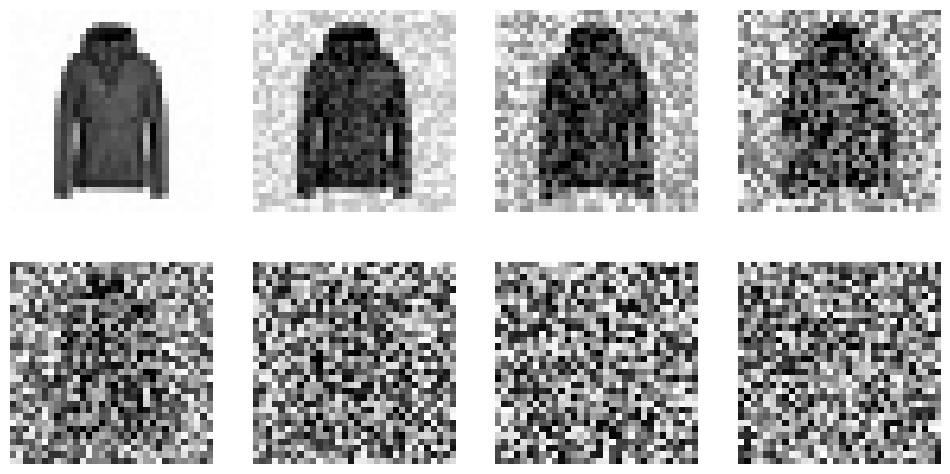

In [8]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)
timesteps = torch.linspace(0, 999, 8).long()
batch = next(iter(train_dataloader))

# データセットから８名の画像を読み込みノイズの量を徐々に増やしていく
x = batch["images"][0].expand([8, 1, 32, 32])
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

In [9]:
from torch.nn import functional as F
from tqdm import tqdm

from genaibook.core import get_device

#スケジューラー初期化
schedeler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02
)

num_epochs = 25
lr = 3e-4 #学習率
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
losses = [] #後で表示するために損失を保存しておくリスト

device = get_device()
model = model.to(device)

#モデルを訓練する（時間かかる）
for epoch in (progress := tqdm(range(num_epochs))):
  for step, batch in(
      inner := tqdm(
          enumerate(train_dataloader),
          position=0,
          leave=True,
          total=len(train_dataloader)
      )
  ):
    #入力画像とクラスを読み込む
    clean_images = batch["images"].to(device)
    class_labels = batch["labels"].to(device)

    #画像に加えるノイズをサンプリングする
    noise = torch.randn(clean_images.shape).to(device)

    #各画像ごとにランダムなタイムステップをサンプリングする
    timesteps = torch.randint(
        0,
        scheduler.config.num_train_timesteps,
        (clean_images.shape[0],),
        device=device
    ).long()

    #タイムステップごとのノイズ量に従って画像にノイズを加える
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

    #ノイズに対するモデルの予測値を得る
    #モデルにクラスラベルを渡している点に注目
    noise_pred = model(noisy_images, timesteps, class_labels=class_labels, return_dict=False)[0]

    #予測値と実際のノイズを比較する
    loss = F.mse_loss(noise_pred, noise)

    # 損失を更新し、表示する
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")

    #後で表示できるように損失を保存する
    losses.append(loss.item())

    #この損失に基づきモデルのパラメーターを更新する
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

 16%|█▌        | 4/25 [12:47<1:07:08, 191.83s/it]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)

5.1.4 サンプリング

これで任意の画像とラベルを受け取って予測を実行するモデルができた。
ランダムノイズから開始し任意のクラスラベルを指定して繰り返しノイズ除去を行うことで好きなクラスのサンプル画像を生成できる。

In [ ]:
def generate_from_class(class_to_generate, n_samples=8):
  sample = torch.randn(n_samples, 1, 32, 32).to(device)
  class_labels = [class_to_generate] * n_samples
  class_labels = torch.tensor(class_labels).to(device)

  for _, t in tqdm(enumerate(scheduler.timesteps)):
    # モデルによる予測値を得る
    with torch.inference_mode():
      noise_pred = model(sample, t, class_labels=class_labels).sample

    # ステップごとにサンプルを更新する
    sample = scheduler.step(noise_pred, t, sample).prev_sample

  return sample.clip(-1, 1) * 0.5 + 0,5

In [ ]:
# 試しに Tシャツの画像（クラス０）を生成してみる
images = generate_from_class(0)
show_images(images, nrows=2)

In [ ]:
# スニーカー（クラス７）も生成してみる
images = generate_from_class(7)
show_images(images, nrows=2)

In [ ]:
# 最後にブーツ（クラス９）も生成してみる
images = generate_from_class(9)
show_images(images, nrows=2)

5.2 潜在拡散による効率化の向上

これで条件付きモデルの訓練が可能になったので、あとはスケールを大きくすればいいかと思いきや、そんな単純な話ではない。
画像サイズが大きくなるにつれて、計算量も急激に増加する。特にセルフアテンションを使用した場合に顕著で、入力量が増えると計算量は２乗に比例して増加する。

潜在拡散はこの問題を解消するために、別途用意した変分オートエンコーダー（VAE）をを活用する。
VAE を用いて入力画像を８分の１にまで圧縮し入力に渡すようにする。

これが Stable Diffusion である。

5.3 Stable Diffusion の構成要素

Stable Diffusion はテキストプロンプトに基づいて画像を生成できる潜在拡散モデル。
専門的な知識がなくても Stable Diffusion を使って画像を生成できる Web サイトやアプリが何百と存在する。

本説では」これを可能にしているすべての構成要素を詳しく解説する。

In [16]:
import torch
from diffusers import StableDiffusionPipeline
from genaibook.core import get_device

device = get_device()

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    variant="fp16",
).to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

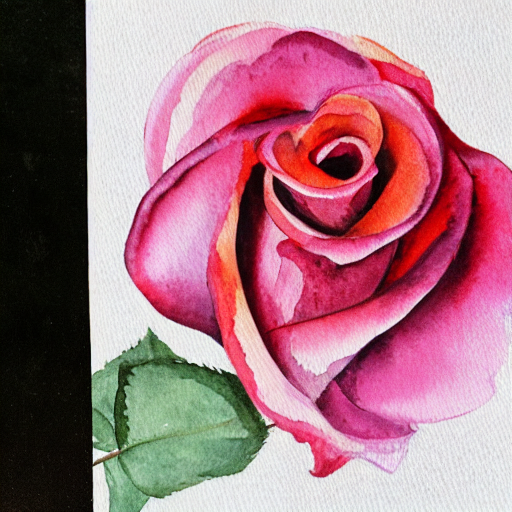

In [17]:
pipe("Watercolor illustration of a rose").images[0]

5.3.1 テキストエンコーダー

Stable Diffusion はノイズが加えられた画像が与えられると、クラスラベルなどの追加の手がかりをもとにノイズを除去した画像を生成しようとする。
この時、追加の手がかりとなる情報というのがテキストプロンプトになるというわけ。

このテキストを埋め込みとして渡す必要があるため、テキストエンコーダーを使う。
これをタイムステップやノイズを加えた潜在ベクトルとともに UNet に渡す。

これを実現するために Stable Diffusion は訓練済みの Transformer モデルを活用している。
すべてのトークンのベクトルを一つにまとめるだけでなく、トークンごとのベクトルを個別に保持し、Unet への条件付け情報として利用する。こうすることで、プロンプト全体の意味だけでなく、トークン個別の情報を活用できる。
これらの埋め込みは CLIP モデルの内部表現から抽出されることから、 **encoder隠れ状態**と呼ばれることがある。

実際にテキストをエンコードする仕組みを見ていく。

In [18]:
prompt = "A photograph of a puppy."

# テキストをトークンの列に変換する
text_input = pipe.tokenizer(
    prompt,
    return_tensors="pt"
)

# トークンと対応するIDを出力する
for t in text_input["input_ids"][0]:
  print(t, pipe.tokenizer.decoder.get(int(t)))

tensor(49406) <|startoftext|>
tensor(320) a</w>
tensor(8853) photograph</w>
tensor(539) of</w>
tensor(320) a</w>
tensor(6829) puppy</w>
tensor(269) .</w>
tensor(49407) <|endoftext|>


In [19]:
text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
print("Text embeddings shape:", text_embeddings.shape)

Text embeddings shape: torch.Size([1, 8, 768])


5.3.2 変分オートエンコーダー

VAE は大きな画像を圧縮した表現にし、元の画像に再構成する。

画像を読み込み、VAE で圧縮、復元後の画像がどうなるか見てみよう。

<Axes: >

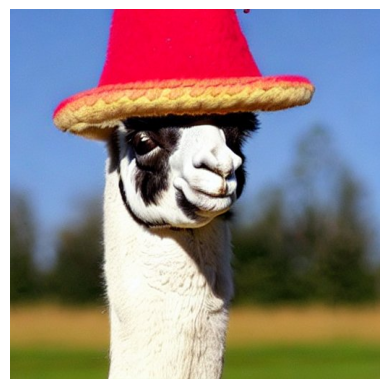

In [20]:
from genaibook.core import load_image, show_image, SampleURL

im = load_image(
    SampleURL.LlamaExample,
    size=(512, 512)
)
show_image(im)

In [21]:
# この画像を VAE に通してみる。

with torch.inference_mode():
  #画像を処理する
  tensor_im = transforms.ToTensor()(im).unsqueeze(0).to(device) * 2 - 1
  tensor_im = tensor_im.half()

  # 画像をエンコードする
  latent = pipe.vae.encode(tensor_im)

  #潜在分布からサンプリングする
  latents = latent.latent_dist.sample()
  latents = latents * 0.18215

latents.shape

torch.Size([1, 4, 64, 64])

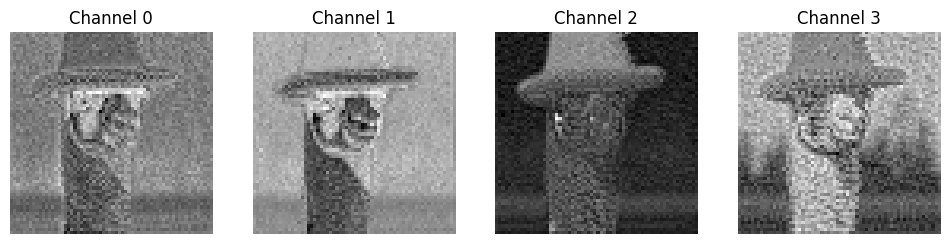

In [22]:
from genaibook.core import show_images

show_images(
    [l for l in latents[0]],
    titles=[f"Channel {i}" for i in range (latents.shape[1])],
    ncols=4
)

<Axes: >

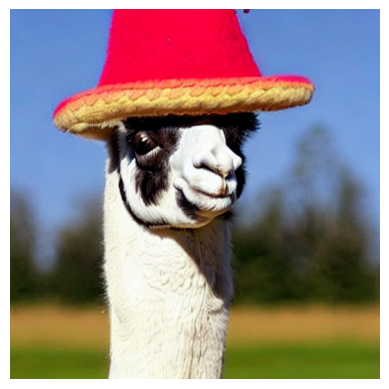

In [23]:
# 次はこの潜在表現を画像に直す

with torch.inference_mode():
  image = pipe.vae.decode(latents / 0.18215).sample

image = (image / 2 + 0.5).clamp(0, 1)
show_image(image[0].float())

5.3.3 UNet

Stable Diffusion で使われている UNet は前章の画像生成で使ったものとよく似ている。
画像生成の際は UNet は３チャネルの画像を受け取っていたのに対し、Stable Diffusion の UNet では４チャネルの潜在表現を受け取る。

復習）
タイムステップ埋め込み：通常のタイムステップは整数なので、これをそのままニューラルネットワークの入力として与えるのでは、モデルが時間的な順序や関連性を効果的に学習できない。そこでタイムステップを埋め込みに変換し、連続的なベクトル表現に変換して入力として渡す。

5.3.4 Stable Diffusion XL

2023年夏、Stable Diffusion の新しい改良版である Stable Diffsion XL がリリースされた。
主に以下の改善が施されている。

- プロンプトの表現をより適切に捉える大型テキストエンコーダー：２つのテキストエンコーダーの出力を用いる
- あらゆる情報を条件付けとして利用
  - 元の画像サイズ
  - クロップの座標
  - 対象のアスペクト比
- 高解像度：1024*1024 の画像を出力されるように設計されている
- 約３倍に大型化した UNet：増加した条件付けに対応するためにクロスアテンションのコンテキストが増大している
- 改良された VAE
- リファイナーモデル：高品質な画像のみを用いて、ノイズスケジュールの最初の２０％の間にのみ訓練されるモデル。このモデルのおかげで、SDXL はノイズの少ない画像から非常に精細で高品質な質感や細部を生成する方法を理解できる。


利点も多いが、当然モデルの実行速度が遅くなり、メモリ使用量も増加する。

5.3.5 FLUX, SD3, 動画

拡散モデルの分野は今もなお減速の兆しを見せておらず、さまざまなサイズや解像度に対応したり、プロンプトの理解やテキスト生成の能力も向上している。
動画などにも発展している。
とはいえ、これらの発展的な技術も根幹は本章で学んだものと変わりはない。

5.3.6 分類フリーガイダンス（CFG（Classifier-Free Guidance））

テキストを条件付けとして利用するための工夫がさまざまとられるが、モデルは依然としてテキストよりもノイズ付き画像をもとに予測する傾向にある。これは入力されるテキストが画像の内容と関連が希薄になるためなので、ある意味当然のこと。
しかしテキスト入力に基づく画像生成をやらせたいのにこの状況では困る。

これを軽減するために、**ガイダンス**という方法を取る。ガイダンスは特定の方向に生成結果を偏らせたい場合に、損失関数を修正して方向修正するというもの。

さらに別の方法として**分類フリーガイダンス**と呼ばれるテクニックがある。これは条件付き拡散モデルと非条件権付き拡散モデルの生成結果を組み合わせるもの。
訓練時には条件なし（テキストなし）で訓練をさせる。推論時にテキストプロンプトを条件として使用する場合と、条件として使用しない場合の２つの予測を行い、それらの差分を利用して最終的な予測を生成する。
この時、テキスト条件付きモデルの予測を強めに押し出すように調整できる。この度合いは、ガイダンススケールと呼ばれるスケーリング係数によって調整される。

In [24]:
images = []
prompt = "An oil painting of a collie in a top hat"
for guidance_scale in [1, 2, 4, 12]:
  torch.manual_seed(0)
  image = pipe(prompt, guidance_scale=guidance_scale).images[0]
  images.append(image)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

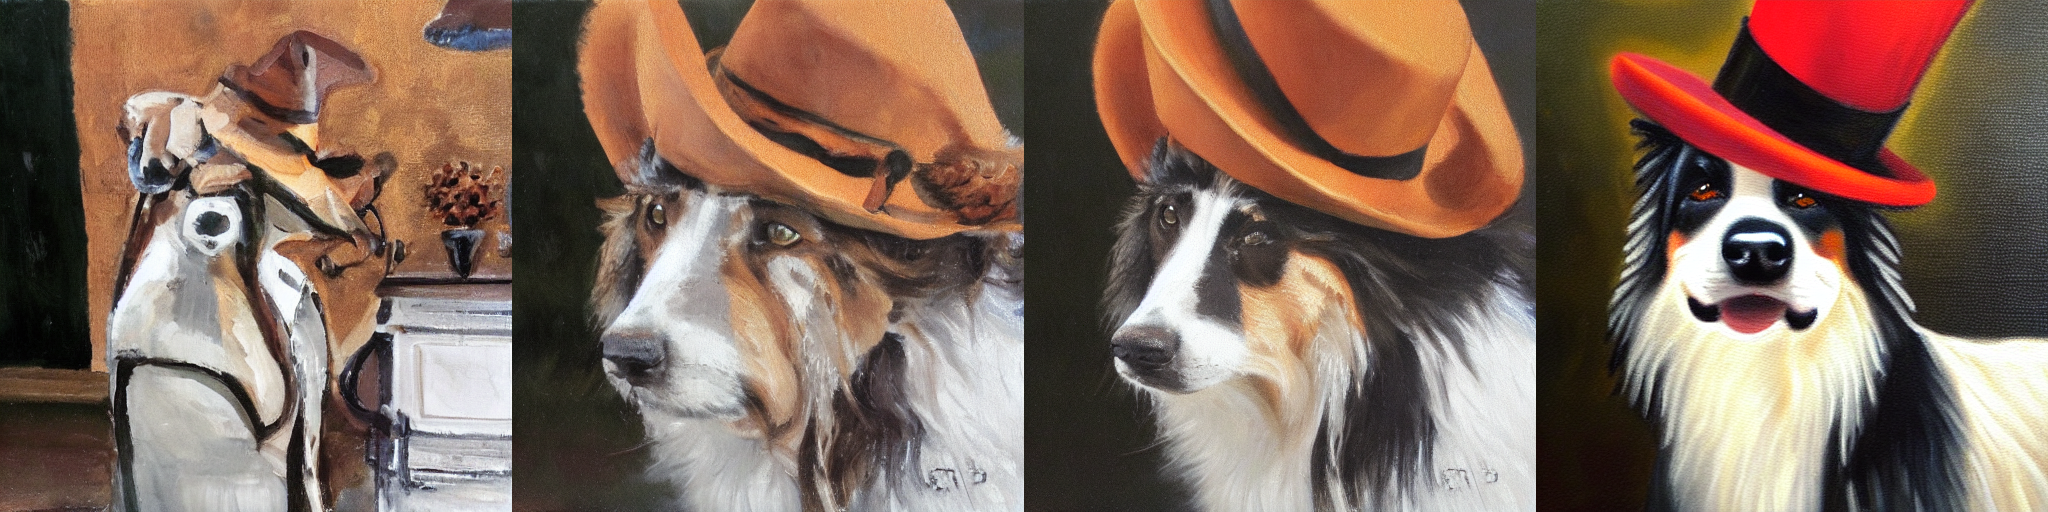

In [26]:
from genaibook.core import image_grid

image_grid(images, 1, 4)

5.4 全てをまとめる：コメント付きサンプリングループ

これですべての構成要素が何をするかがわかった。
パイプラインを使わずに各要素を組み合わせて画像を生成してみよう。

In [40]:
# 設定情報
prompt = [
    "Acrylic palette knife painting of a flower"
] # 何を生成したいのか

height = 512
width = 512
num_inference_steps = 30
guidance_scale = 7.5 # CFG のガイダンススケール
seed = 42

In [41]:
# テキストの埋め込みを作成する処理

#n入力をトークン化する
text_input = pipe.tokenizer(
    prompt,
    padding="max_length",
    return_tensors="pt"
)

#非条件付き入力についても同様に処理する
uncond_input = pipe.tokenizer(
    "",
    padding="max_length",
    return_tensors="pt"
)

# 両方の埋め込みをテキストエンコーダーにとおす
with torch.inference_mode():
  text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
  uncond_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]

#２つのテキスト埋め込みを結合する
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

In [42]:
# 次にランダムな潜在表現を作成し、必要な推論ステップ数をスケジューラーに設定する

# スケジューラーを準備する
pipe.scheduler.set_timesteps(num_inference_steps)

# ランダムに初期化した潜在表現を準備する
latents = (
    torch.randn(
        (1, pipe.unet.in_channels, height // 8, width // 8),
    )
    .to(device)
    .half()
)
latents = latents * pipe.scheduler.init_noise_sigma

/tmp/ipykernel_2472/2958931017.py:9: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, pipe.unet.in_channels, height // 8, width // 8),


In [43]:
# サンプリングステップをループし、各段階でモデルの予測を得てこれを使って潜在表現を更新する。

for t in pipe.scheduler.timesteps:
  #2つのテクスト埋め込み（条件付きと非条件付き）に対応するよう潜在表現を２つ複製する
  latent_input = torch.cat([latents] * 2)
  latent_input = pipe.scheduler.scale_model_input(latent_input, t)

  # 潜在表現それぞれについてノイズ残差を予測する
  with torch.inference_mode():
    noise_pred = pipe.unet(
        latent_input, t, encoder_hidden_states=text_embeddings
    ).sample

  # 条件付きと非条件付きの予測結果を分ける
  noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

  # CFG を実行する
    # noise_pred_uncond: テキストなし、デフォルトの場合の予測値
    # noise_pred: テキストあり、プロンプトに素直に従った場合の予測値
    # (noise_pred_text - noise_pred_uncond) (テキストによる方向性): **「テキストが指定する方向はどこか？」という『方向ベクトル』**を抽出
    # guidance_scale: （方向性を）どれくらい強調するか
  noise_pred = noise_pred_uncond + guidance_scale * (
      noise_pred_text - noise_pred_uncond
  )

  # 次のタイムステップように潜在表現を更新する
  latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

<Axes: >

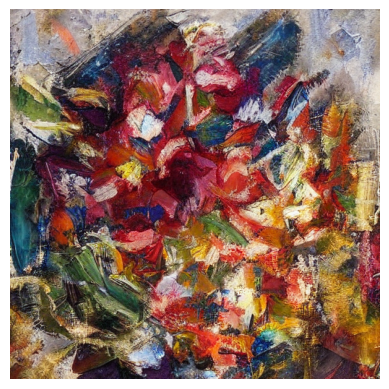

In [44]:
# 画像の潜在表現をスケーリングし、VAE ででコードする
latents = 1 / pipe.vae.config.scaling_factor * latents
with torch.inference_mode():
  image = pipe.vae.decode(latents).sample
image = (image / 2 + 0.5).clamp(0, 1)

show_image(image[0].float())

5.5 オープンデータとオープンモデル